In [78]:
import pandas as pd
import glob
import re
import matplotlib.pyplot as plt
import os

In [79]:
base_dir = "latency_output/20260421_145433_q11"

files = []

for root, dirs, filenames in os.walk(base_dir):
    for name in filenames:
        if "part-" in name:   # Spark files are usually part-00000...
            files.append(os.path.join(root, name))

print("Found files:", len(files))
for f in files[:10]:
    print(f)

Found files: 9
latency_output/20260421_145433_q11/2026-04-21--15/.part-f95cc62c-4556-4870-99ed-1221984c34d9-1.inprogress.84c0dc67-7847-40b2-a39d-a0976782075c
latency_output/20260421_145433_q11/2026-04-21--15/.part-b1fad0e9-3efa-4a1c-acd3-27c80265a5b0-0.inprogress.ee156f44-77e4-4453-8605-eb8635422cb1
latency_output/20260421_145433_q11/2026-04-21--15/.part-b1fad0e9-3efa-4a1c-acd3-27c80265a5b0-1.inprogress.8b403be8-c6d5-4f9f-9837-03fce803966a
latency_output/20260421_145433_q11/2026-04-21--15/.part-667b0da3-dc24-4372-9223-5d1192b51b66-0.inprogress.bab41d43-38dd-4a34-a81c-ba05d467567d
latency_output/20260421_145433_q11/2026-04-21--15/.part-f95cc62c-4556-4870-99ed-1221984c34d9-0.inprogress.c76af743-48c1-4022-b89a-0285450c3c0e
latency_output/20260421_145433_q11/2026-04-21--15/.part-667b0da3-dc24-4372-9223-5d1192b51b66-1.inprogress.6f047f01-2fd7-4f8e-b968-7f192468a50f
latency_output/20260421_145433_q11/2026-04-21--14/.part-27cdb4bb-ded1-4bd5-b96a-6d777b6f21a7-2.inprogress.1d14236e-867a-42ec-a4

In [80]:
pwd

'/Users/mdtahsinsharif/ece1724_project/Benchmark-Streaming-Databases/flink/flink_with_kafka'

In [81]:
rows = []
pattern = re.compile(
    r"window_start=(.*?), window_end=(.*?), records=(\d+), "
    r"avg_latency_ms=([\d.]+), p50_ms=(\d+), p95_ms=(\d+), p99_ms=(\d+)"
)

In [82]:
for file in files:
    print(file)
    with open(file, "r") as f:
        for line in f:
            match = pattern.search(line)
            if match:
                rows.append({
                    "window_start": match.group(1),
                    "window_end": match.group(2),
                    "records": int(match.group(3)),
                    "avg_latency_ms": float(match.group(4)),
                    "p50_ms": int(match.group(5)),
                    "p95_ms": int(match.group(6)),
                    "p99_ms": int(match.group(7))
                })

latency_output/20260421_145433_q11/2026-04-21--15/.part-f95cc62c-4556-4870-99ed-1221984c34d9-1.inprogress.84c0dc67-7847-40b2-a39d-a0976782075c
latency_output/20260421_145433_q11/2026-04-21--15/.part-b1fad0e9-3efa-4a1c-acd3-27c80265a5b0-0.inprogress.ee156f44-77e4-4453-8605-eb8635422cb1
latency_output/20260421_145433_q11/2026-04-21--15/.part-b1fad0e9-3efa-4a1c-acd3-27c80265a5b0-1.inprogress.8b403be8-c6d5-4f9f-9837-03fce803966a
latency_output/20260421_145433_q11/2026-04-21--15/.part-667b0da3-dc24-4372-9223-5d1192b51b66-0.inprogress.bab41d43-38dd-4a34-a81c-ba05d467567d
latency_output/20260421_145433_q11/2026-04-21--15/.part-f95cc62c-4556-4870-99ed-1221984c34d9-0.inprogress.c76af743-48c1-4022-b89a-0285450c3c0e
latency_output/20260421_145433_q11/2026-04-21--15/.part-667b0da3-dc24-4372-9223-5d1192b51b66-1.inprogress.6f047f01-2fd7-4f8e-b968-7f192468a50f
latency_output/20260421_145433_q11/2026-04-21--14/.part-27cdb4bb-ded1-4bd5-b96a-6d777b6f21a7-2.inprogress.1d14236e-867a-42ec-a4f7-2584bfe5e207

In [83]:
rows[:2]

[{'window_start': '2026-04-21 15:01:35',
  'window_end': '2026-04-21 15:01:40',
  'records': 120,
  'avg_latency_ms': 1074.42,
  'p50_ms': 1100,
  'p95_ms': 1909,
  'p99_ms': 2008},
 {'window_start': '2026-04-21 15:01:40',
  'window_end': '2026-04-21 15:01:45',
  'records': 86,
  'avg_latency_ms': 1063.69,
  'p50_ms': 1039,
  'p95_ms': 1892,
  'p99_ms': 1981}]

In [84]:
# --------------------------------------------------
# 2. Convert to DataFrame
# --------------------------------------------------
df = pd.DataFrame(rows)

# convert timestamps
df["window_start"] = pd.to_datetime(df["window_start"])
df["window_end"] = pd.to_datetime(df["window_end"])

# --------------------------------------------------
# 3. IMPORTANT: remove duplicates (you have repeated windows)
# --------------------------------------------------
df = df.groupby("window_start").mean(numeric_only=True).reset_index()

# recompute window_end (optional consistency)
df["window_end"] = df["window_start"] + pd.Timedelta(seconds=5)
df["throughput_per_sec"] = df["records"] / 5
# --------------------------------------------------
# 4. Sort
# --------------------------------------------------
df = df.sort_values("window_start")
df["window_index"] = range(len(df))

# convert to seconds (5s window size)
df["time_sec"] = df["window_index"] * 5

In [85]:
df["window_start"] = pd.to_datetime(df["window_start"])
df = df.sort_values("window_start")

# convert to relative time (seconds from start)
df["time_sec"] = (df["window_start"] - df["window_start"].min()).dt.total_seconds()

In [86]:
#df = df[df["time_sec"] <= 90]
df = df.reset_index(drop=True)
df["time_sec"] = df["time_sec"] - df["time_sec"].min()

In [87]:
ROLLING_WINDOW = 5  # try 5–10 depending on noise level

df["avg_smooth"] = df["avg_latency_ms"].rolling(ROLLING_WINDOW).mean()
df["p50_smooth"] = df["p50_ms"].rolling(ROLLING_WINDOW).mean()
df["p95_smooth"] = df["p95_ms"].rolling(ROLLING_WINDOW).mean()
df["p99_smooth"] = df["p99_ms"].rolling(ROLLING_WINDOW).mean()

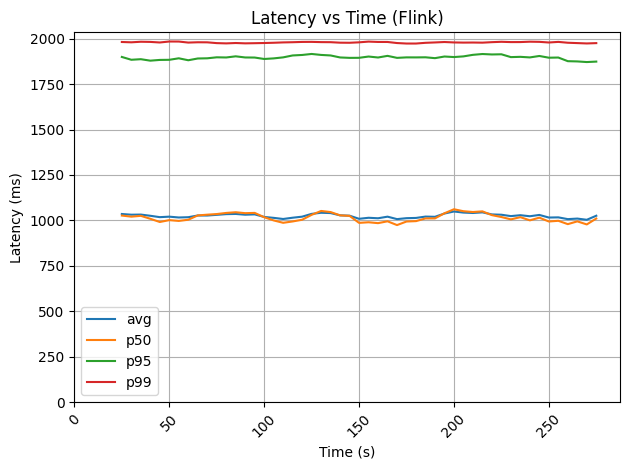

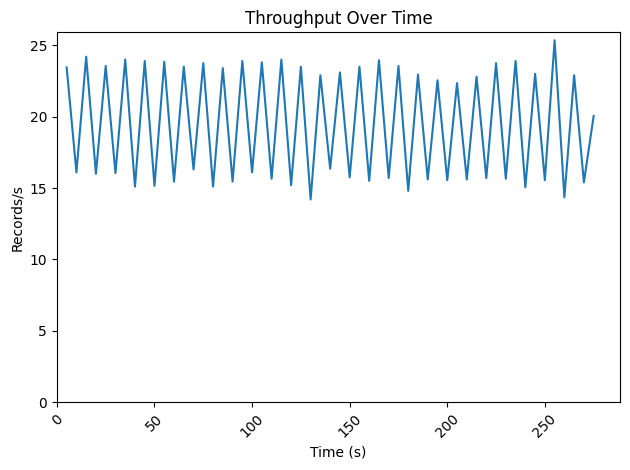

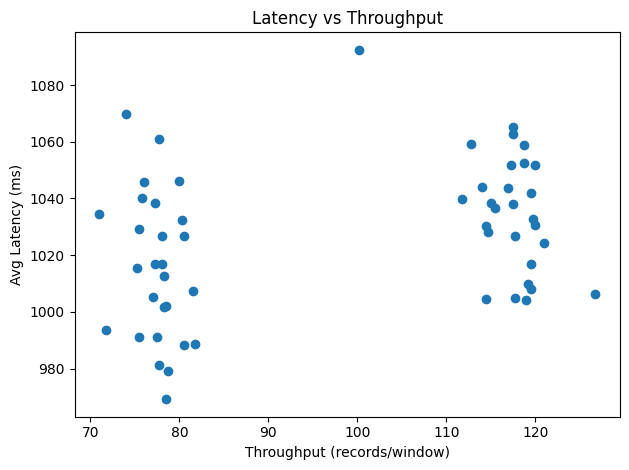

In [88]:
# --------------------------------------------------
# 5. Plot 1: Latency trends
# --------------------------------------------------


plt.figure()

plt.plot(df["time_sec"], df["avg_smooth"], label="avg")
plt.plot(df["time_sec"], df["p50_smooth"], label="p50")
plt.plot(df["time_sec"], df["p95_smooth"], label="p95")
plt.plot(df["time_sec"], df["p99_smooth"], label="p99")

plt.legend()
plt.title("Latency vs Time (Flink)")
plt.xlabel("Time (s)")
plt.ylabel("Latency (ms)")
plt.xticks(rotation=45)

plt.xlim(left=0)
plt.ylim(bottom=0)

plt.tight_layout()
plt.grid(True)
plt.savefig("figures/q11_10k/latency_vs_time_0.png", dpi=300, bbox_inches="tight")
plt.show()

# --------------------------------------------------
# 6. Plot 2: Throughput
# --------------------------------------------------
'''plt.figure()
plt.plot(df["window_start"], df["throughput_per_sec"])
plt.title("Throughput Over Time")
plt.xlabel("Window")
plt.ylabel("Records/s")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
'''
plt.figure()

plt.plot(df["time_sec"], df["throughput_per_sec"])

plt.title("Throughput Over Time")
plt.xlabel("Time (s)")
plt.ylabel("Records/s")

plt.xlim(left=0)
plt.ylim(bottom=0)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 7. Plot 3: Latency vs throughput correlation (optional but useful)
# --------------------------------------------------
plt.figure()
plt.scatter(df["records"], df["avg_latency_ms"])
plt.title("Latency vs Throughput")
plt.xlabel("Throughput (records/window)")
plt.ylabel("Avg Latency (ms)")
plt.tight_layout()
plt.show()